In [ ]:
# ============================================================
# CELL 1 — INSTALLATION
# ============================================================

!pip -q install gradio imageio imageio-ffmpeg matplotlib numpy

In [ ]:
# ============================================================
# CELL 2 — IMPORTS AND CONFIGURATION
# ============================================================

import os
import math
import shutil
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from pathlib import Path

# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/neural_network_intro")
FRAME_DIR = PROJECT_DIR / "frames"
VIDEO_DIR = PROJECT_DIR / "video"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
FRAME_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

VIDEO_PATH = VIDEO_DIR / "neural_network_introduction.mp4"

# ------------------------------------------------------------
# Rendering configuration
# ------------------------------------------------------------

WIDTH = 1280
HEIGHT = 720
FPS = 30

DPI = 100

FIG_W = WIDTH / DPI
FIG_H = HEIGHT / DPI

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

np.random.seed(42)

print("Project directory:", PROJECT_DIR)
print("Video output:", VIDEO_PATH)
print("Resolution:", f"{WIDTH}x{HEIGHT}")
print("FPS:", FPS)

Project directory: /content/neural_network_intro
Video output: /content/neural_network_intro/video/neural_network_introduction.mp4
Resolution: 1280x720
FPS: 30


In [ ]:
# ============================================================
# CELL 3 — ANIMATION ENGINE
# ============================================================

class NeuralAnimation:

    def __init__(self, width=WIDTH, height=HEIGHT, fps=FPS):

        self.width = width
        self.height = height
        self.fps = fps

        self.fig = plt.figure(
            figsize=(width / DPI, height / DPI),
            dpi=DPI,
            facecolor="black"
        )

        self.ax = self.fig.add_axes([0, 0, 1, 1])

        self.ax.set_xlim(0, 1)
        self.ax.set_ylim(0, 1)
        self.ax.axis("off")

    # --------------------------------------------------------
    # Reset canvas
    # --------------------------------------------------------

    def clear(self):

        self.ax.clear()

        self.ax.set_xlim(0, 1)
        self.ax.set_ylim(0, 1)

        self.ax.axis("off")

        self.fig.patch.set_facecolor("black")
        self.ax.set_facecolor("black")

    # --------------------------------------------------------
    # Text
    # --------------------------------------------------------

    def text(
        self,
        x,
        y,
        text,
        size=24,
        weight="normal",
        alpha=1.0,
        ha="center",
        va="center"
    ):

        return self.ax.text(
            x,
            y,
            text,
            fontsize=size,
            fontweight=weight,
            color="white",
            alpha=alpha,
            ha=ha,
            va=va,
            family="DejaVu Sans"
        )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    def title(self, text, subtitle=None):

        self.text(
            0.5,
            0.90,
            text,
            size=34,
            weight="bold"
        )

        if subtitle:

            self.text(
                0.5,
                0.84,
                subtitle,
                size=18,
                alpha=0.75
            )

    # --------------------------------------------------------
    # Neuron
    # --------------------------------------------------------

    def neuron(
        self,
        x,
        y,
        radius=0.035,
        label=None,
        alpha=1.0
    ):

        circle = plt.Circle(
            (x, y),
            radius,
            fill=False,
            linewidth=2.5,
            edgecolor="white",
            alpha=alpha
        )

        self.ax.add_patch(circle)

        if label:

            self.text(
                x,
                y,
                label,
                size=16,
                alpha=alpha
            )

        return circle

    # --------------------------------------------------------
    # Connection
    # --------------------------------------------------------

    def connection(
        self,
        x1,
        y1,
        x2,
        y2,
        alpha=1.0,
        linewidth=1.8
    ):

        self.ax.plot(
            [x1, x2],
            [y1, y2],
            linewidth=linewidth,
            color="white",
            alpha=alpha,
            zorder=0
        )

    # --------------------------------------------------------
    # Arrow
    # --------------------------------------------------------

    def arrow(
        self,
        x1,
        y1,
        x2,
        y2,
        alpha=1.0
    ):

        self.ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=2,
                color="white",
                alpha=alpha
            )
        )

    # --------------------------------------------------------
    # Layer
    # --------------------------------------------------------

    def layer(
        self,
        x,
        neuron_count,
        spacing=0.13,
        labels=None,
        alpha=1.0
    ):

        center_y = 0.48

        positions = []

        for i in range(neuron_count):

            y = center_y + (
                i - (neuron_count - 1) / 2
            ) * spacing

            label = None

            if labels and i < len(labels):
                label = labels[i]

            self.neuron(
                x,
                y,
                label=label,
                alpha=alpha
            )

            positions.append((x, y))

        return positions

    # --------------------------------------------------------
    # Fully connected layers
    # --------------------------------------------------------

    def connect_layers(
        self,
        layer_a,
        layer_b,
        alpha=1.0
    ):

        for x1, y1 in layer_a:

            for x2, y2 in layer_b:

                self.connection(
                    x1,
                    y1,
                    x2,
                    y2,
                    alpha=alpha
                )

    # --------------------------------------------------------
    # Equation
    # --------------------------------------------------------

    def equation(
        self,
        expression,
        y=0.16,
        size=27,
        alpha=1.0
    ):

        self.text(
            0.5,
            y,
            expression,
            size=size,
            alpha=alpha
        )

    # --------------------------------------------------------
    # Render current frame
    # --------------------------------------------------------

    def render_frame(self):

        self.fig.canvas.draw()

        image = np.asarray(
            self.fig.canvas.buffer_rgba()
        )

        image = image[:, :, :3]

        return image.copy()

    # --------------------------------------------------------
    # Save frame
    # --------------------------------------------------------

    def save_frame(self, path):

        frame = self.render_frame()

        imageio.imwrite(
            path,
            frame
        )

    # --------------------------------------------------------
    # Close
    # --------------------------------------------------------

    def close(self):

        plt.close(self.fig)

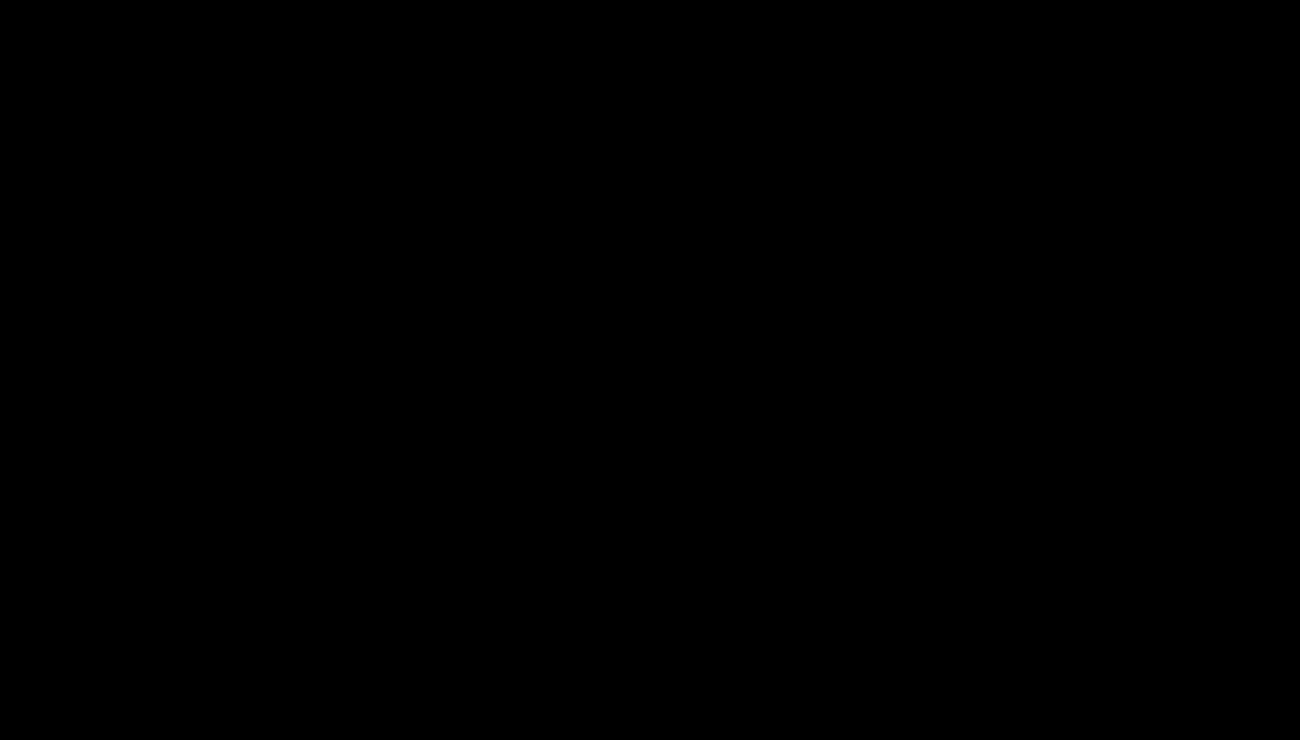

In [ ]:
# ============================================================
# CELL 4 — FRAME HELPERS
# ============================================================

anim = NeuralAnimation()


def frame_range(seconds):

    return max(1, int(seconds * FPS))


def fade_alpha(frame, total_frames):

    if total_frames <= 1:
        return 1.0

    return min(
        1.0,
        max(
            0.0,
            frame / (total_frames - 1)
        )
    )


def render_scene(
    scene_function,
    duration,
    scene_name
):

    scene_dir = FRAME_DIR / scene_name

    scene_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    total_frames = frame_range(duration)

    print(
        f"Rendering {scene_name}: "
        f"{total_frames} frames"
    )

    for frame_number in range(total_frames):

        progress = (
            frame_number /
            max(1, total_frames - 1)
        )

        anim.clear()

        scene_function(
            anim,
            progress
        )

        frame_path = (
            scene_dir /
            f"frame_{frame_number:05d}.png"
        )

        anim.save_frame(
            frame_path
        )

    return scene_dir

In [ ]:
# ============================================================
# CELL 5 — SCENE 01
# ============================================================

def scene_01(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "WHAT IS DEEP LEARNING?"
    )

    anim.text(
        0.5,
        0.70,
        "A neural network learns patterns",
        size=28,
        weight="bold",
        alpha=alpha
    )

    anim.text(
        0.5,
        0.63,
        "from numerical representations of data.",
        size=23,
        alpha=alpha
    )

    # Data

    anim.text(
        0.18,
        0.40,
        "DATA",
        size=22,
        weight="bold",
        alpha=alpha
    )

    for i in range(3):

        y = 0.34 + i * 0.07

        anim.neuron(
            0.18,
            y,
            radius=0.025,
            label=str(i + 1),
            alpha=alpha
        )

    # Network

    layer1 = anim.layer(
        0.45,
        4,
        spacing=0.10,
        alpha=alpha
    )

    layer2 = anim.layer(
        0.65,
        4,
        spacing=0.10,
        alpha=alpha
    )

    anim.connect_layers(
        layer1,
        layer2,
        alpha=alpha
    )

    # Output

    anim.neuron(
        0.84,
        0.48,
        radius=0.035,
        label="ŷ",
        alpha=alpha
    )

    anim.text(
        0.84,
        0.39,
        "PREDICTION",
        size=18,
        alpha=alpha
    )

    # Arrows

    anim.arrow(
        0.24,
        0.48,
        0.40,
        0.48,
        alpha=alpha
    )

    anim.arrow(
        0.70,
        0.48,
        0.80,
        0.48,
        alpha=alpha
    )

    anim.text(
        0.5,
        0.16,
        "Data → Neural Network → Learned Representation",
        size=22,
        alpha=alpha
    )

In [ ]:
# ============================================================
# CELL 6 — SCENE 02
# ============================================================

def scene_02(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "THE ARTIFICIAL NEURON"
    )

    # Inputs

    inputs = [
        (0.12, 0.68, "x₁"),
        (0.12, 0.50, "x₂"),
        (0.12, 0.32, "x₃")
    ]

    weights = ["w₁", "w₂", "w₃"]

    for i, ((x, y, label), weight) in enumerate(
        zip(inputs, weights)
    ):

        anim.neuron(
            x,
            y,
            radius=0.035,
            label=label,
            alpha=alpha
        )

        anim.arrow(
            x + 0.04,
            y,
            0.43,
            0.50,
            alpha=alpha
        )

        anim.text(
            0.28,
            y + 0.035,
            weight,
            size=18,
            alpha=alpha
        )

    # Neuron

    anim.neuron(
        0.50,
        0.50,
        radius=0.075,
        label="Σ",
        alpha=alpha
    )

    anim.text(
        0.50,
        0.39,
        "Weighted Sum",
        size=18,
        alpha=alpha
    )

    # Bias

    anim.text(
        0.61,
        0.68,
        "b",
        size=25,
        weight="bold",
        alpha=alpha
    )

    anim.arrow(
        0.61,
        0.64,
        0.55,
        0.56,
        alpha=alpha
    )

    # Activation

    anim.arrow(
        0.58,
        0.50,
        0.72,
        0.50,
        alpha=alpha
    )

    anim.neuron(
        0.77,
        0.50,
        radius=0.065,
        label="f",
        alpha=alpha
    )

    anim.text(
        0.77,
        0.39,
        "Activation",
        size=18,
        alpha=alpha
    )

    # Output

    anim.arrow(
        0.84,
        0.50,
        0.94,
        0.50,
        alpha=alpha
    )

    anim.text(
        0.95,
        0.50,
        "y",
        size=27,
        weight="bold",
        alpha=alpha,
        ha="left"
    )

In [ ]:
# ============================================================
# CELL 7 — SCENE 03
# ============================================================

def scene_03(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "THE MATHEMATICAL OPERATION"
    )

    anim.text(
        0.5,
        0.67,
        "Each input is multiplied by a learned weight.",
        size=24,
        alpha=alpha
    )

    anim.equation(
        "x₁w₁ + x₂w₂ + x₃w₃",
        y=0.51,
        size=32,
        alpha=alpha
    )

    anim.text(
        0.5,
        0.41,
        "+ bias",
        size=26,
        alpha=alpha
    )

    anim.equation(
        "z = Σ(xᵢwᵢ) + b",
        y=0.27,
        size=34,
        alpha=alpha
    )

    anim.text(
        0.5,
        0.15,
        "The result becomes the neuron's pre-activation value.",
        size=19,
        alpha=alpha
    )

In [ ]:
# ============================================================
# CELL 8 — SCENE 04
# ============================================================

def scene_04(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "ACTIVATION: ReLU"
    )

    anim.text(
        0.5,
        0.77,
        "The activation function transforms the neuron's value.",
        size=22,
        alpha=alpha
    )

    # Axes

    anim.ax.plot(
        [0.20, 0.80],
        [0.45, 0.45],
        color="white",
        linewidth=1.5,
        alpha=alpha
    )

    anim.ax.plot(
        [0.50, 0.50],
        [0.20, 0.72],
        color="white",
        linewidth=1.5,
        alpha=alpha
    )

    # ReLU curve

    x = np.linspace(
        0.50,
        0.80,
        100
    )

    y = 0.45 + (
        x - 0.50
    ) * 0.9

    anim.ax.plot(
        x,
        y,
        linewidth=4,
        color="white",
        alpha=alpha
    )

    # Negative section

    anim.text(
        0.33,
        0.35,
        "negative → 0",
        size=21,
        alpha=alpha
    )

    anim.text(
        0.67,
        0.65,
        "positive → value",
        size=21,
        alpha=alpha
    )

    anim.equation(
        "ReLU(z) = max(0, z)",
        y=0.14,
        size=30,
        alpha=alpha
    )

In [ ]:
# ============================================================
# CELL 9 — SCENE 05
# ============================================================

def scene_05(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "FROM ONE NEURON TO A LAYER"
    )

    positions = anim.layer(
        0.50,
        5,
        spacing=0.105,
        alpha=alpha
    )

    for x, y in positions:

        anim.text(
            x + 0.09,
            y,
            "neuron",
            size=16,
            alpha=alpha,
            ha="left"
        )

    anim.text(
        0.5,
        0.15,
        "A layer contains multiple neurons processing information in parallel.",
        size=21,
        alpha=alpha
    )

In [ ]:
# ============================================================
# CELL 10 — SCENE 06
# ============================================================

def scene_06(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "BUILDING THE NEURAL NETWORK"
    )

    input_layer = anim.layer(
        0.15,
        4,
        spacing=0.105,
        alpha=alpha
    )

    hidden1 = anim.layer(
        0.38,
        5,
        spacing=0.09,
        alpha=alpha
    )

    hidden2 = anim.layer(
        0.62,
        5,
        spacing=0.09,
        alpha=alpha
    )

    output_layer = anim.layer(
        0.85,
        3,
        spacing=0.12,
        alpha=alpha
    )

    # Connections

    anim.connect_layers(
        input_layer,
        hidden1,
        alpha=alpha
    )

    anim.connect_layers(
        hidden1,
        hidden2,
        alpha=alpha
    )

    anim.connect_layers(
        hidden2,
        output_layer,
        alpha=alpha
    )

    # Layer names

    anim.text(
        0.15,
        0.18,
        "INPUT",
        size=19,
        weight="bold",
        alpha=alpha
    )

    anim.text(
        0.38,
        0.18,
        "HIDDEN",
        size=19,
        weight="bold",
        alpha=alpha
    )

    anim.text(
        0.62,
        0.18,
        "HIDDEN",
        size=19,
        weight="bold",
        alpha=alpha
    )

    anim.text(
        0.85,
        0.18,
        "OUTPUT",
        size=19,
        weight="bold",
        alpha=alpha
    )

    anim.text(
        0.5,
        0.10,
        "Information moves forward through connected layers.",
        size=18,
        alpha=alpha
    )

In [ ]:
# ============================================================
# CELL 11 — SCENE 07
# ============================================================

def scene_07(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "HOW DOES THE NETWORK LEARN?"
    )

    stages = [
        ("INPUT", 0.12),
        ("PREDICTION", 0.32),
        ("ERROR", 0.52),
        ("WEIGHT\nUPDATE", 0.72),
        ("IMPROVED\nPREDICTION", 0.90)
    ]

    for i, (label, x) in enumerate(stages):

        anim.neuron(
            x,
            0.50,
            radius=0.065,
            alpha=alpha
        )

        anim.text(
            x,
            0.36,
            label,
            size=16,
            weight="bold",
            alpha=alpha
        )

        if i < len(stages) - 1:

            anim.arrow(
                x + 0.07,
                0.50,
                stages[i + 1][1] - 0.07,
                0.50,
                alpha=alpha
            )

    anim.text(
        0.5,
        0.76,
        "Training repeatedly adjusts the network's parameters.",
        size=23,
        alpha=alpha
    )

    anim.text(
        0.5,
        0.16,
        "The goal is to reduce prediction error.",
        size=21,
        alpha=alpha
    )

In [ ]:
# ============================================================
# CELL 12 — SCENE 08
# ============================================================

def scene_08(anim, progress):

    alpha = min(1.0, progress * 3)

    anim.title(
        "FROM NEURAL NETWORKS TO VGG16"
    )

    stages = [
        ("NEURON", 0.12),
        ("LAYERS", 0.29),
        ("DEEP\nNETWORK", 0.46),
        ("CNN", 0.63),
        ("VGG16", 0.82)
    ]

    for i, (label, x) in enumerate(stages):

        anim.neuron(
            x,
            0.50,
            radius=0.065,
            label="●",
            alpha=alpha
        )

        anim.text(
            x,
            0.36,
            label,
            size=17,
            weight="bold",
            alpha=alpha
        )

        if i < len(stages) - 1:

            anim.arrow(
                x + 0.07,
                0.50,
                stages[i + 1][1] - 0.07,
                0.50,
                alpha=alpha
            )

    anim.text(
        0.5,
        0.74,
        "The same fundamental ideas scale into deep convolutional networks.",
        size=21,
        alpha=alpha
    )

    anim.text(
        0.5,
        0.15,
        "Next: examining how VGG16 transforms visual information.",
        size=20,
        alpha=alpha
    )

In [ ]:
# ============================================================
# CELL 13 — RENDER ALL SCENES
# ============================================================

SCENES = [
    (scene_01, 7, "scene_01_deep_learning"),
    (scene_02, 8, "scene_02_neuron"),
    (scene_03, 7, "scene_03_mathematics"),
    (scene_04, 7, "scene_04_relu"),
    (scene_05, 6, "scene_05_layer"),
    (scene_06, 9, "scene_06_network"),
    (scene_07, 8, "scene_07_training"),
    (scene_08, 7, "scene_08_vgg16")
]

scene_directories = []

for scene_function, duration, name in SCENES:

    directory = render_scene(
        scene_function,
        duration,
        name
    )

    scene_directories.append(directory)

print()
print("All scenes rendered.")

Rendering scene_01_deep_learning: 210 frames
Rendering scene_02_neuron: 240 frames
Rendering scene_03_mathematics: 210 frames
Rendering scene_04_relu: 210 frames
Rendering scene_05_layer: 180 frames
Rendering scene_06_network: 270 frames
Rendering scene_07_training: 240 frames
Rendering scene_08_vgg16: 210 frames

All scenes rendered.


In [ ]:
# ============================================================
# CELL 14 — ASSEMBLE MP4
# ============================================================

def collect_frames():

    frames = []

    for scene_dir in scene_directories:

        scene_frames = sorted(
            scene_dir.glob("frame_*.png")
        )

        frames.extend(scene_frames)

    return frames


all_frames = collect_frames()

print(
    "Total frames:",
    len(all_frames)
)

print(
    "Approximate duration:",
    round(len(all_frames) / FPS, 2),
    "seconds"
)

# ------------------------------------------------------------
# Encode video
# ------------------------------------------------------------

with imageio.get_writer(
    VIDEO_PATH,
    fps=FPS,
    codec="libx264",
    quality=8,
    pixelformat="yuv420p"
) as writer:

    for i, frame_path in enumerate(all_frames):

        frame = imageio.imread(frame_path)

        writer.append_data(frame)

        if i % 100 == 0:

            print(
                f"Encoding: {i}/{len(all_frames)}"
            )

print()
print("VIDEO CREATED:")
print(VIDEO_PATH)

Total frames: 1770
Approximate duration: 59.0 seconds
Encoding: 0/1770
Encoding: 100/1770
Encoding: 200/1770
Encoding: 300/1770
Encoding: 400/1770
Encoding: 500/1770
Encoding: 600/1770
Encoding: 700/1770
Encoding: 800/1770
Encoding: 900/1770
Encoding: 1000/1770
Encoding: 1100/1770
Encoding: 1200/1770
Encoding: 1300/1770
Encoding: 1400/1770
Encoding: 1500/1770
Encoding: 1600/1770
Encoding: 1700/1770

VIDEO CREATED:
/content/neural_network_intro/video/neural_network_introduction.mp4


In [ ]:
# ============================================================
# CELL 15 — PREVIEW VIDEO
# ============================================================

from IPython.display import Video, display

display(
    Video(
        str(VIDEO_PATH),
        embed=True,
        width=900
    )
)

In [ ]:
# Run this cell in Google Colab.
# It builds an interactive Gradio presentation for “The 4 Network Animals”.

!pip -q install gradio matplotlib pandas

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Rectangle, Ellipse
import gradio as gr

plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 130})

ANIMALS = {
    "1 · Primary Producer — Acacia MLP": {
        "animal": "Acacia Tree / Flora",
        "network": "Feedforward Network (FNN / MLP)",
        "parallel": "Foundational synthesis: raw numerical inputs are transformed into useful predictions through dense baseline layers.",
        "structure": "Input layer → fully connected hidden layers + ReLU → output layer",
        "works": "A vector moves forward through matrix multiplications and nonlinear activations. During training, backpropagation adjusts weights to reduce prediction loss.",
        "role": "Dense layers are the bedrock components found inside many larger deep-learning systems, much like producers supply energy to an ecosystem.",
        "applications": "Tabular classification, regression, baseline risk scoring",
        "color": "#2E8B57",
        "emoji": "🌳",
        "kind": "mlp"
    },
    "2 · Primary Consumer — Chameleon CNN": {
        "animal": "Chameleon / Receptive Forager",
        "network": "Convolutional Neural Network (CNN)",
        "parallel": "Spatial feature extraction: localized optical filters scan visual grids for edges, textures, shapes, and objects.",
        "structure": "Convolution kernels → ReLU → pooling → fully connected decision head",
        "works": "Shared kernels slide over image matrices to make feature maps. Early layers detect local edges; deeper layers combine these into richer visual patterns.",
        "role": "Localized receptive fields parallel a chameleon examining a visual scene for useful spatial patterns.",
        "applications": "Computer vision, MRI/CT imaging, autonomous-vehicle obstacle detection",
        "color": "#C17A13",
        "emoji": "🦎",
        "kind": "cnn"
    },
    "3 · Apex Predator — Wolf Pack LSTM": {
        "animal": "Timber Wolf / Sequential Tracker",
        "network": "Long Short-Term Memory (LSTM / RNN)",
        "parallel": "Temporal processing: internal memory gates retain meaningful footsteps from the past and discard noise.",
        "structure": "Recurrent loop with forget gate, input gate, output gate, cell state Cₜ, and hidden state hₜ",
        "works": "At every time step, gates decide what to forget, what new information to write into memory, and what hidden-state signal to pass onward.",
        "role": "The model tracks a sequence over time, preserving long-range context that a static network can miss.",
        "applications": "Natural-language processing, financial forecasting, time-series anomaly detection",
        "color": "#496D89",
        "emoji": "🐺",
        "kind": "lstm"
    },
    "4 · Decomposer — Mycelium Autoencoder": {
        "animal": "Mycelium / Fungus",
        "network": "Autoencoder (AE)",
        "parallel": "Compression and reconstruction: complex material becomes a compact latent code, then is rebuilt into a useful approximation.",
        "structure": "Encoder → bottleneck latent space z → decoder → reconstruction",
        "works": "The encoder compresses high-dimensional input to a low-dimensional latent representation. The decoder reconstructs the input while training minimizes reconstruction error, often L2/MSE.",
        "role": "Like a decomposer recycling matter, it extracts essential structure from complex data and can support denoising, initialization, and anomaly discovery.",
        "applications": "Dimensionality reduction, image denoising, anomaly detection, unsupervised features",
        "color": "#7C4D8C",
        "emoji": "🍄",
        "kind": "ae"
    },
}


def box(ax, x, y, w, h, text, color, fontsize=9, alpha=1.0):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.04",
                           facecolor=color, edgecolor="#24323D", linewidth=1.3, alpha=alpha)
    ax.add_patch(patch)
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=fontsize, color="white", wrap=True, weight="bold")


def arrow(ax, a, b, color="#24323D", rad=0):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=14, linewidth=1.5,
                                 color=color, connectionstyle=f"arc3,rad={rad}"))


def setup(ax, title, subtitle, color):
    ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")
    ax.set_facecolor("#F7FAFC")
    ax.text(0.35, 5.55, title, fontsize=17, weight="bold", color="#18212A")
    ax.text(0.35, 5.15, subtitle, fontsize=9.5, color="#425466")
    ax.plot([0.35, 9.65], [4.92, 4.92], color=color, linewidth=3)


def architecture_figure(key):
    item = ANIMALS[key]
    color, kind = item["color"], item["kind"]
    fig, ax = plt.subplots(figsize=(11.5, 5.7))
    setup(ax, f"{item['emoji']}  {item['network']}", item["structure"], color)

    if kind == "mlp":
        layers = [(1.1, 4, "Raw inputs\n(tabular vector)"), (3.45, 5, "Dense + ReLU"), (5.8, 4, "Dense + ReLU"), (8.15, 2, "Output\nprediction")]
        for x, n, label in layers:
            ys = np.linspace(0.75, 4.3, n)
            for y in ys:
                ax.add_patch(Circle((x,y), 0.16, facecolor=color, edgecolor="#1F2D38", lw=1.1))
            ax.text(x, 0.3, label, ha="center", va="center", fontsize=9, color="#263746", weight="bold")
        for i in range(len(layers)-1):
            x1,n1,_ = layers[i]; x2,n2,_ = layers[i+1]
            for y1 in np.linspace(0.75,4.3,n1):
                for y2 in np.linspace(0.75,4.3,n2):
                    ax.plot([x1+.16,x2-.16],[y1,y2], color=color, alpha=.22, lw=.8)
        ax.text(5.0, 4.55, "Forward propagation → loss → backpropagation", ha="center", fontsize=10, color=color, weight="bold")

    elif kind == "cnn":
        grid = np.arange(64).reshape(8,8)
        ax.imshow(grid, cmap="YlOrBr", extent=(0.55,2.45,1.35,3.25), origin="lower")
        ax.add_patch(Rectangle((1.05,1.82), .72,.72, fill=False, edgecolor="#1F2D38", linewidth=2))
        ax.text(1.5,.75,"Input image\nvisual grid",ha="center",fontsize=9,weight="bold",color="#263746")
        arrow(ax,(2.55,2.3),(3.25,2.3),color)
        for x in [3.55,4.35,5.15]:
            ax.add_patch(Rectangle((x,1.45),.5,1.7,facecolor=color,alpha=.35,edgecolor="#24323D"))
            for yy in np.linspace(1.6,2.95,5): ax.plot([x+.08,x+.42],[yy,yy],color=color,lw=1)
        ax.text(4.35,.75,"Convolution\nfeature maps",ha="center",fontsize=9,weight="bold",color="#263746")
        arrow(ax,(5.75,2.3),(6.45,2.3),color)
        for i,x in enumerate([6.65,7.1,7.55]):
            ax.add_patch(Circle((x,2.65),.15,facecolor=color,edgecolor="#24323D"))
            ax.add_patch(Circle((x,2.05),.15,facecolor=color,edgecolor="#24323D"))
        ax.text(7.1,.75,"Pooling +\ndecision head",ha="center",fontsize=9,weight="bold",color="#263746")
        arrow(ax,(7.8,2.35),(8.55,2.35),color)
        box(ax,8.65,1.72,.85,1.25,"Class\nlabel",color,9)
        ax.text(5.0,4.25,"Shared filters scan locally: edges → textures → shapes → objects",ha="center",fontsize=11,color=color,weight="bold")

    elif kind == "lstm":
        steps = [1.0,3.0,5.0,7.0]
        labels = ["x₁", "x₂", "x₃", "x₄"]
        for x,lbl in zip(steps,labels):
            box(ax,x,1.35,1.15,1.2,"LSTM\ncell",color,10)
            ax.text(x+.58,.85,lbl,ha="center",fontsize=11,weight="bold",color="#263746")
            ax.text(x+.58,2.8,"hₜ",ha="center",fontsize=9,color="#263746")
        for x in steps[:-1]:
            arrow(ax,(x+1.15,2.0),(x+1.85,2.0),color)
            arrow(ax,(x+1.15,3.72),(x+1.85,3.72),"#8A3A3A")
        ax.plot([1.45,8.7],[3.72,3.72],color="#8A3A3A",lw=2.2)
        ax.text(4.95,4.05,"Cell state Cₜ: long-term trail / memory",ha="center",fontsize=10,color="#8A3A3A",weight="bold")
        ax.text(4.95,4.65,"Forget gate  •  Input gate  •  Output gate",ha="center",fontsize=11,color=color,weight="bold")
        ax.text(4.95,.25,"A sequence is interpreted through time, not as isolated snapshots.",ha="center",fontsize=10,color="#425466")

    else:
        box(ax,.65,1.55,1.45,1.55,"High-dimensional\ninput x",color,10)
        arrow(ax,(2.15,2.33),(3.0,2.33),color)
        box(ax,3.05,1.55,1.35,1.55,"Encoder\ncompress",color,10)
        arrow(ax,(4.45,2.33),(5.2,2.33),color)
        ax.add_patch(Circle((5.7,2.33),.56,facecolor="#F2C94C",edgecolor="#24323D",lw=1.5))
        ax.text(5.7,2.33,"z\nlatent",ha="center",va="center",fontsize=10,weight="bold",color="#24323D")
        arrow(ax,(6.25,2.33),(7.0,2.33),color)
        box(ax,7.05,1.55,1.35,1.55,"Decoder\nrebuild",color,10)
        arrow(ax,(8.45,2.33),(9.15,2.33),color)
        box(ax,9.2,1.55,.55,1.55,"x̂",color,12)
        ax.text(5.0,4.25,"Reconstruction objective: minimize error between x and x̂",ha="center",fontsize=11,color=color,weight="bold")
        ax.text(5.0,.55,"Complex data → essential representation → reconstructed output",ha="center",fontsize=10,color="#425466")
    fig.tight_layout()
    return fig


def ecosystem_figure():
    fig, ax = plt.subplots(figsize=(11.5, 5.7))
    ax.set_xlim(0,10); ax.set_ylim(0,6); ax.axis("off"); ax.set_facecolor("#F7FAFC")
    ax.text(.35,5.55,"The 4 Network Animals: a learning ecosystem",fontsize=17,weight="bold",color="#18212A")
    ax.text(.35,5.15,"Each ecological role emphasizes a different way neural networks handle information.",fontsize=9.5,color="#425466")
    positions=[(1.5,3.0),(4.0,3.0),(6.5,3.0),(8.7,3.0)]
    keys=list(ANIMALS.keys())
    short=["PRIMARY\nPRODUCER", "PRIMARY\nCONSUMER", "APEX\nPREDATOR", "DECOMPOSER"]
    for (x,y),key,s in zip(positions,keys,short):
        item=ANIMALS[key]
        ax.add_patch(Ellipse((x,y),1.65,1.65,facecolor=item['color'],alpha=.92,edgecolor="#24323D",lw=1.5))
        ax.text(x,y+.25,item['emoji'],ha="center",va="center",fontsize=24)
        ax.text(x,y-.45,s,ha="center",va="center",fontsize=8,color="white",weight="bold")
        ax.text(x,1.55,item['network'].replace(" (FNN / MLP)","\n(FNN / MLP)").replace(" (CNN)","\n(CNN)").replace(" (LSTM / RNN)","\n(LSTM / RNN)").replace(" (AE)","\n(AE)"),ha="center",va="center",fontsize=8.6,color="#263746",weight="bold")
    for i in range(3): arrow(ax,(positions[i][0]+.86,3),(positions[i+1][0]-.86,3),"#425466")
    arrow(ax,(8.55,2.2),(2.25,2.2),"#7C4D8C",rad=.28)
    ax.text(5.4,.55,"Information cycle: baseline synthesis → spatial perception → temporal tracking → compression and renewal",ha="center",fontsize=11,color="#263746",weight="bold")
    fig.tight_layout()
    return fig


def details(key):
    item=ANIMALS[key]
    md=f"""## {item['emoji']} {item['animal']} — {item['network']}

**Ecological & architectural parallel:** {item['parallel']}

### Network structure
{item['structure']}

### How it works
{item['works']}

### Ecosystem role
{item['role']}

### Representative applications
{item['applications']}
"""
    return architecture_figure(key), md


def mini_demo(key, value):
    x=np.linspace(-3,3,300)
    fig,ax=plt.subplots(figsize=(10,3.5))
    item=ANIMALS[key]; c=item['color']; k=item['kind']
    if k=="mlp":
        y=np.maximum(0, np.sin(x*float(value))*1.2 + .25*x)
        ax.plot(x,y,color=c,lw=3,label="ReLU-activated hidden representation")
        ax.set_title("MLP example: nonlinear transformation through a dense hidden layer")
        ax.set_xlabel("Input feature value"); ax.set_ylabel("Activation")
    elif k=="cnn":
        n=int(value); img=np.zeros((n,n)); img[:,n//2-1:n//2+1]=1; img[n//3:n//3+2,:]=.7
        kernel=np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
        from scipy.signal import convolve2d
        out=convolve2d(img,kernel,mode='same')
        ax.imshow(out,cmap='magma'); ax.set_title("CNN example: edge-response feature map after a convolution filter")
        ax.axis('off')
    elif k=="lstm":
        t=np.arange(int(value)); signal=np.sin(t*.35)+.38*np.sin(t*1.55)
        memory=[]; m=0
        for s in signal:
            m=.82*m+.18*s; memory.append(m)
        ax.plot(t,signal,color="#9AA7B0",lw=2,label="Incoming sequence")
        ax.plot(t,memory,color=c,lw=3,label="Memory-like smoothed state")
        ax.set_title("LSTM intuition: retained state smooths noisy sequential observations")
        ax.set_xlabel("Time step"); ax.legend()
    else:
        dims=int(value); rng=np.random.default_rng(4); X=rng.normal(size=(90,dims)); X[:,0]+=np.linspace(-2,2,90)
        u,s,v=np.linalg.svd(X-X.mean(axis=0),full_matrices=False); Z=(X-X.mean(axis=0))@v[:2].T
        ax.scatter(Z[:,0],Z[:,1],c=np.linspace(0,1,len(Z)),cmap="viridis",s=30)
        ax.set_title(f"Autoencoder intuition: {dims} dimensions compressed to a 2D latent space")
        ax.set_xlabel("Latent feature z₁");ax.set_ylabel("Latent feature z₂")
    ax.grid(alpha=.2); fig.tight_layout(); return fig

summary = pd.DataFrame([
    ["1", "Primary Producer", "🌳 Acacia / Flora", "FNN / MLP", "Dense baseline synthesis", "Tabular data, regression"],
    ["2", "Primary Consumer", "🦎 Chameleon", "CNN", "Spatial feature extraction", "Vision, medical imaging"],
    ["3", "Apex Predator", "🐺 Timber Wolf", "LSTM / RNN", "Temporal sequence tracking", "NLP, forecasting"],
    ["4", "Decomposer", "🍄 Mycelium / Fungus", "Autoencoder", "Compression + reconstruction", "Denoising, anomaly detection"],
], columns=["Level", "Trophic role", "Animal", "Network", "Shared idea", "Applications"])

with gr.Blocks(theme=gr.themes.Soft(), title="The 4 Network Animals") as demo:
    gr.Markdown("# 🌿 The 4 Network Animals\n### An ecological metaphor for four foundational neural-network architectures")
    gr.Markdown("Use the selector to explore a presentation-ready depiction, architecture diagram, explanation, and small interactive example for each network animal.")
    with gr.Tab("Ecosystem overview"):
        gr.Plot(value=ecosystem_figure())
        gr.Dataframe(value=summary, interactive=False, wrap=True)
        gr.Markdown("**Interpretive note:** This is a teaching metaphor, not a biological classification of AI. The models are distinct tools that can also be combined in real systems.")
    with gr.Tab("Explore an animal"):
        selector=gr.Dropdown(choices=list(ANIMALS.keys()), value=list(ANIMALS.keys())[0], label="Choose a network animal")
        with gr.Row():
            architecture=gr.Plot(value=architecture_figure(list(ANIMALS.keys())[0]), label="Architecture depiction")
        explain=gr.Markdown(value=details(list(ANIMALS.keys())[0])[1])
        selector.change(details, inputs=selector, outputs=[architecture,explain])
    with gr.Tab("Interactive examples"):
        example_selector=gr.Dropdown(choices=list(ANIMALS.keys()), value=list(ANIMALS.keys())[0], label="Choose an example")
        control=gr.Slider(1,10,value=3,step=1,label="Example control")
        example_plot=gr.Plot(value=mini_demo(list(ANIMALS.keys())[0],3))
        example_selector.change(lambda k: gr.update(value=3, minimum=1, maximum=10, step=1, label="Example control"), inputs=example_selector, outputs=control)
        example_selector.change(mini_demo, inputs=[example_selector,control], outputs=example_plot)
        control.change(mini_demo, inputs=[example_selector,control], outputs=example_plot)
    with gr.Tab("Presenter notes"):
        gr.Markdown("""## Suggested 60–90 second narrative

1. **Acacia MLP:** Begin with raw structured data. Dense layers synthesize basic signals into a prediction.
2. **Chameleon CNN:** Move to visual data. Convolution filters scan an image locally, turning pixels into meaningful spatial features.
3. **Wolf LSTM:** Add time. Recurrent memory lets the network follow patterns and preserve relevant history.
4. **Mycelium Autoencoder:** Close the loop. It compresses complex data into essential latent structure, then reconstructs it for denoising or anomaly detection.

The unifying message: architectures differ because the structure of information differs—tables, images, sequences, and high-dimensional representations each call for a different strategy.
""")

demo.launch(share=True, debug=True)


/tmp/ipykernel_3360/1589701435.py:240: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="The 4 Network Animals") as demo:
/tmp/ipykernel_3360/1589701435.py:175: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3360/1589701435.py:175: UserWarning: Glyph 129422 (\N{LIZARD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3360/1589701435.py:175: UserWarning: Glyph 128058 (\N{WOLF FACE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3360/1589701435.py:175: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.13/dist-packages/gradio/processing_utils.py:83: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.savefig(ou

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2859864c04b2843771.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import time
import random

def slow_print(text, delay=0.03):
    """Prints text slowly for a narrative effect."""
    for char in text:
        print(char, end='', flush=True)
        time.sleep(delay)
    print()
    time.sleep(0.5)

def acacia_mlp_game():
    slow_print("\n=== 🌳 LEVEL 1: ACACIA MLP (Primary Producer) ===")
    slow_print("You are the Acacia Tree. You must synthesize raw numerical inputs through dense layers.")
    slow_print("To produce energy, multiply the incoming resources by your network weights and sum them up.")

    water = random.randint(2, 5)
    sun = random.randint(2, 5)
    weight_water = 3
    weight_sun = 4

    print(f"\n[Inputs]: Water = {water}, Sun = {sun}")
    print(f"[Weights]: Water_Weight = {weight_water}, Sun_Weight = {weight_sun}")

    correct_activation = (water * weight_water) + (sun * weight_sun)

    while True:
        try:
            choice = int(input("Calculate the Feedforward Activation (Water*W1 + Sun*W2): ").strip())
            if choice == correct_activation:
                slow_print("✅ Activation successful! The Acacia synthesizes baseline predictions.")
                break
            else:
                slow_print("❌ Prediction loss is too high. Backpropagate and try the math again.")
        except ValueError:
            print("Please enter a valid number.")

def chameleon_cnn_game():
    slow_print("\n=== 🦎 LEVEL 2: CHAMELEON CNN (Primary Consumer) ===")
    slow_print("You are the Chameleon. You extract spatial features from visual grids.")
    slow_print("Your convolution kernel is searching for the 'Bug Pattern': [1, 8, 1].")

    # Create a 1D visual grid and hide the bug
    grid = [0, 0, 0, 0, 0, 0, 0, 0]
    bug_index = random.randint(0, 5)
    grid[bug_index:bug_index+3] = [1, 8, 1]

    print(f"\n[Visual Array]: {grid}")

    while True:
        try:
            choice = int(input("At what starting index (0-7) does the pattern [1, 8, 1] begin? ").strip())
            if choice == bug_index:
                slow_print("✅ Feature map extracted! The Chameleon's receptive field found the target.")
                break
            else:
                slow_print("❌ Missed the spatial feature. Slide your kernel and try again.")
        except ValueError:
            print("Please enter a valid number.")

def wolf_lstm_game():
    slow_print("\n=== 🐺 LEVEL 3: TIMBER WOLF LSTM (Apex Predator) ===")
    slow_print("You are the Wolf Pack. You track temporal sequences and preserve long-range context.")
    slow_print("You hear a sequence of sounds. Use your 'Forget Gate' to drop the noise, and your 'Input Gate' to remember the prey.")

    sequence = ["Wind", "Deer", "Crunch", "Rabbit"]
    print(f"\n[Incoming Time Steps]: {sequence}")
    slow_print("System Prompt: Forget 'Wind' and 'Crunch'. Retain the prey in your cell state.")

    while True:
        choice = input("Enter the two prey animals to keep in memory (comma separated, e.g., Bear, Bird): ").strip().title()
        if "Deer" in choice and "Rabbit" in choice:
            slow_print("✅ Sequence tracked! The Wolf preserves the hidden state across time.")
            break
        else:
            slow_print("❌ Memory corrupted by noise. Check your gates and try again.")

def mycelium_ae_game():
    slow_print("\n=== 🍄 LEVEL 4: MYCELIUM AUTOENCODER (Decomposer) ===")
    slow_print("You are the Mycelium. You compress complex inputs into a latent code, then reconstruct them.")
    slow_print("You receive noisy, high-dimensional data corrupted with leetspeak and symbols.")

    complex_data = "[[T.h.e__Ec0sys.tem_is..B.a.l.a.nc3d]]"
    latent_truth = "The Ecosystem is Balanced"

    print(f"\n[High-Dimensional Input x]: {complex_data}")
    slow_print("System Prompt: Denoise the input. Replace numbers with their missing letters (0->o, 3->e), turn underscores into spaces, and remove all punctuation.")

    while True:
        choice = input("Enter the reconstructed output (x̂): ").strip()
        # Case insensitive check
        if choice.lower() == latent_truth.lower():
            slow_print("✅ Reconstruction successful! The Mycelium has extracted the essential structure.")
            break
        else:
            slow_print("❌ High reconstruction error (MSE). Try compressing again.")

def final_ecosystem_match():
    slow_print("\n=== 🧠 FINAL CYCLE: ECOSYSTEM SYNTHESIS ===")
    slow_print("To complete the cycle, match the animal to its neural network architecture.")

    architectures = [
        "A: Convolutional Neural Network (CNN)",
        "B: Autoencoder (AE)",
        "C: Feedforward Network (FNN / MLP)",
        "D: Long Short-Term Memory (LSTM / RNN)"
    ]

    answers = {
        "Acacia (Producer)": "C",
        "Chameleon (Consumer)": "A",
        "Wolf (Apex Predator)": "D",
        "Mycelium (Decomposer)": "B"
    }

    for arch in architectures:
        print(arch)

    score = 0
    for entity in answers.keys():
        while True:
            choice = input(f"\nWhich architecture is the {entity}? (A/B/C/D): ").strip().upper()
            if choice in ["A", "B", "C", "D"]:
                if choice == answers[entity]:
                    slow_print(f"Correct. The {entity} is synchronized.")
                    score += 1
                else:
                    slow_print(f"Incorrect. Ecological mismatch.")
                break
            else:
                print("Please enter A, B, C, or D.")

    if score == 4:
        slow_print("\n🌟 ECOSYSTEM BALANCED! You have mastered the 4 Network Animals! 🌟")
    else:
        slow_print(f"\nCycle disrupted. You scored {score}/4. Rerun the script to try again.")

def main():
    slow_print("Welcome to The 4 Network Animals.")
    slow_print("An interactive ecological journey through neural network architectures.")
    time.sleep(1)

    acacia_mlp_game()
    time.sleep(1)
    chameleon_cnn_game()
    time.sleep(1)
    wolf_lstm_game()
    time.sleep(1)
    mycelium_ae_game()
    time.sleep(1)

    final_ecosystem_match()

if __name__ == "__main__":
    main()


In [ ]:
import time
import random
import os
import sys

# --- TERMINAL UI & COLORS ---
class Colors:
    GREEN = '\033[92m'
    CYAN = '\033[96m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    MAGENTA = '\033[95m'
    RESET = '\033[0m'
    BOLD = '\033[1m'

def clear_screen():
    os.system('cls' if os.name == 'nt' else 'clear')

def type_text(text, speed=0.03, color=Colors.RESET, pause=0.5):
    """Simulates a biological terminal typing effect."""
    sys.stdout.write(color)
    for char in text:
        sys.stdout.write(char)
        sys.stdout.flush()
        # Add slight randomness to typing for realism
        time.sleep(speed + random.uniform(0, 0.02))
    sys.stdout.write(Colors.RESET + '\n')
    time.sleep(pause)

def glitch_text(text, color=Colors.RESET):
    """Simulates a neural misfire."""
    glitch_chars = "!@#$%^&*()_+-=[]{}|;:,.<>?"
    sys.stdout.write(color)
    for char in text:
        if random.random() < 0.1:
            sys.stdout.write(random.choice(glitch_chars))
        else:
            sys.stdout.write(char)
        sys.stdout.flush()
        time.sleep(0.02)
    sys.stdout.write(Colors.RESET + '\n')
    time.sleep(0.3)

# --- GLOBAL GAME STATE ---
entropy = 0.0  # Represents the Loss function

def update_entropy(change):
    global entropy
    entropy += change
    color = Colors.GREEN if entropy < 0.5 else Colors.YELLOW if entropy < 0.8 else Colors.RED
    print(f"\n{color}>> [SYSTEM ENTROPY (LOSS): {entropy:.2f}]{Colors.RESET}")
    if entropy >= 1.0:
        type_text("\n[CRITICAL FAILURE] Entropy limit exceeded. The ecosystem has collapsed.", speed=0.05, color=Colors.RED)
        sys.exit()

# --- LEVEL 1: MLP ---
def acacia_mlp():
    clear_screen()
    type_text("=== 🌳 LEVEL 1: ACACIA MLP (Primary Producer) ===", color=Colors.GREEN, speed=0.02)
    type_text("You are the Acacia. You must route sunlight and water through a 2-layer hidden network.", speed=0.02)

    # Inputs
    sun = random.randint(1, 5)
    water = random.randint(1, 5)

    # Weights
    w_sun_h1, w_water_h1 = 2, -1  # Node 1 focuses on sun
    w_sun_h2, w_water_h2 = -1, 3  # Node 2 focuses on water

    type_text(f"\n[INPUT LAYER] Sun = {sun} | Water = {water}", color=Colors.YELLOW)
    time.sleep(1)
    print(f"[HIDDEN NODE 1] (Sun * {w_sun_h1}) + (Water * {w_water_h1})")
    print(f"[HIDDEN NODE 2] (Sun * {w_sun_h2}) + (Water * {w_water_h2})")

    # Calc
    h1 = (sun * w_sun_h1) + (water * w_water_h1)
    h2 = (sun * w_sun_h2) + (water * w_water_h2)
    target = h1 + h2

    while True:
        try:
            ans = int(input(f"\n{Colors.CYAN}Calculate the final Output Sum (H1 + H2) to synthesize glucose: {Colors.RESET}"))
            if ans == target:
                type_text("✅ Forward pass optimal. Glucose synthesized.", color=Colors.GREEN)
                update_entropy(-0.1)
                break
            else:
                type_text("❌ Backpropagation error. Recalculate weights.", color=Colors.RED)
                update_entropy(0.2)
        except ValueError:
            pass
    time.sleep(2)

# --- LEVEL 2: CNN ---
def chameleon_cnn():
    clear_screen()
    type_text("=== 🦎 LEVEL 2: CHAMELEON CNN (Primary Consumer) ===", color=Colors.CYAN, speed=0.02)
    type_text("Slide your convolution matrix (receptive field) to find the prey.", speed=0.02)

    # 5x5 grid
    grid = [[0 for _ in range(5)] for _ in range(5)]
    bug_r, bug_c = random.randint(0, 3), random.randint(0, 3)

    # 2x2 bug
    grid[bug_r][bug_c] = 1
    grid[bug_r+1][bug_c] = 1
    grid[bug_r][bug_c+1] = 1
    grid[bug_r+1][bug_c+1] = 1

    print("\n[VISUAL FIELD TENSOR]")
    for r in range(5):
        row_str = " ".join([str(val) for val in grid[r]])
        print(f"Row {r}: [{row_str}]")

    type_text("\nTarget: Find the 2x2 cluster of 1s (The Bug).", color=Colors.YELLOW)

    while True:
        try:
            r_guess = int(input(f"{Colors.CYAN}Enter the starting ROW (0-3) of the bug: {Colors.RESET}"))
            c_guess = int(input(f"{Colors.CYAN}Enter the starting COLUMN (0-3) of the bug: {Colors.RESET}"))

            if r_guess == bug_r and c_guess == bug_c:
                type_text("✅ Feature map activated! The tongue strikes with precision.", color=Colors.GREEN)
                update_entropy(-0.1)
                break
            else:
                type_text("❌ Missed. The spatial feature was elsewhere.", color=Colors.RED)
                update_entropy(0.2)
        except ValueError:
            pass
    time.sleep(2)

# --- LEVEL 3: LSTM ---
def wolf_lstm():
    clear_screen()
    type_text("=== 🐺 LEVEL 3: TIMBER WOLF LSTM (Apex Predator) ===", color=Colors.RED, speed=0.02)
    type_text("An LSTM relies on temporary memory. Watch the time-series data.", speed=0.02)
    type_text("Your 'Forget Gate' must drop the weather. Your 'Input Gate' must remember the animals.", speed=0.02)

    sequence = ["Wind", "Elk", "Rain", "Snow", "Hare", "Thunder"]
    animals = ["elk", "hare"]

    print(f"\n{Colors.BOLD}Prepare to track the scent...{Colors.RESET}")
    time.sleep(2)

    for item in sequence:
        sys.stdout.write(f"\r[t] Scent detected: {Colors.MAGENTA}{item}{Colors.RESET}        ")
        sys.stdout.flush()
        time.sleep(0.8)

    sys.stdout.write("\r" + " " * 50 + "\r") # clear line

    while True:
        ans = input(f"\n{Colors.CYAN}Enter the TWO animals hidden in your cell state (comma separated): {Colors.RESET}").lower()
        if animals[0] in ans and animals[1] in ans:
            type_text("✅ Long-term dependencies maintained. The pack hunts successfully.", color=Colors.GREEN)
            update_entropy(-0.1)
            break
        else:
            type_text("❌ Vanishing gradient. You forgot the prey.", color=Colors.RED)
            update_entropy(0.2)
    time.sleep(2)

# --- LEVEL 4: AUTOENCODER ---
def mycelium_ae():
    clear_screen()
    type_text("=== 🍄 LEVEL 4: MYCELIUM AUTOENCODER (Decomposer) ===", color=Colors.MAGENTA, speed=0.02)
    type_text("You compress death into a latent space, then reconstruct it into life.", speed=0.02)

    raw_data = "d34d_0rg4n1sm"
    type_text(f"\n[CORRUPTED HIGH-DIMENSIONAL DATA]: {raw_data}", color=Colors.YELLOW)

    type_text("Compressing to Latent Bottleneck...", speed=0.05, color=Colors.CYAN)
    glitch_text("LATENT_CODE: [0.88, -0.4, 0.12, 0.99]", color=Colors.MAGENTA)

    type_text("\nPrompt: Decode the original data by replacing numbers with vowels (3=e, 4=a, 0=o, 1=i) and underscores with spaces.", speed=0.02)

    while True:
        ans = input(f"{Colors.CYAN}Reconstruct Output (x̂): {Colors.RESET}").strip().lower()
        if ans == "dead organism":
            type_text("✅ Perfect reconstruction. The soil is enriched.", color=Colors.GREEN)
            update_entropy(-0.1)
            break
        else:
            type_text("❌ High reconstruction loss (MSE). The nutrients are toxic.", color=Colors.RED)
            update_entropy(0.2)
    time.sleep(2)

def main():
    clear_screen()
    type_text("Initializing Biosphere Neural Engine...", speed=0.05, color=Colors.BOLD)
    time.sleep(1)
    type_text("System Online. Balance the ecosystem. Minimize the Loss function.", color=Colors.CYAN)
    time.sleep(2)

    acacia_mlp()
    chameleon_cnn()
    wolf_lstm()
    mycelium_ae()

    clear_screen()
    if entropy < 0.5:
        type_text("\n🌟 ECOSYSTEM SYNCHRONIZED 🌟", color=Colors.GREEN, speed=0.08)
        type_text("The models have converged. Nature is in harmony.", color=Colors.CYAN)
    else:
        type_text("\n⚠️ ECOSYSTEM UNSTABLE ⚠️", color=Colors.YELLOW, speed=0.08)
        type_text("The models survived, but with high variance. More training epochs required.", color=Colors.YELLOW)

if __name__ == "__main__":
    main()

In [ ]:
import time
from IPython.display import clear_output

class Colors:
    GREEN = '\033[92m'
    CYAN = '\033[96m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    MAGENTA = '\033[95m'
    RESET = '\033[0m'
    BOLD = '\033[1m'

def display_text(msg, color=Colors.RESET):
    """Uses standard print so Colab doesn't buffer/hang before an input prompt."""
    print(f"{color}{msg}{Colors.RESET}")
    time.sleep(0.5)

def acacia_mlp():
    clear_output(wait=True) # Colab-specific way to clear the screen
    display_text("=== 🌳 LEVEL 1: ACACIA MLP (Primary Producer) ===", Colors.GREEN)
    display_text("Initializing L.E.A.F. Protocol (Linear Evaluation & Activation Forward)...", Colors.BOLD)
    display_text("A Multi-Layer Perceptron calculates the dot product of Inputs and Weights, adds Bias, and applies an Activation Function.")

    display_text("\n[INPUT VECTOR (X)]", Colors.YELLOW)
    print("x1 (Water) = 3\nx2 (Sun)   = -2")

    display_text("\n[WEIGHTS (W) & BIAS (b)]", Colors.YELLOW)
    print("w1 = 2\nw2 = 1\nb  = -1")

    display_text("\nYour task: Calculate Z = (x1*w1) + (x2*w2) + b")
    display_text("Then apply the ReLU activation function: Output = max(0, Z)")

    while True:
        try:
            ans = int(input("\nEnter the final Output after ReLU: "))
            if ans == 3:
                display_text("✅ L.E.A.F. forward pass optimal. ReLU activated. Energy synthesized.", Colors.GREEN)
                break
            else:
                display_text("❌ Incorrect calculation. Check your dot product or ReLU logic.", Colors.RED)
        except ValueError:
            pass
    time.sleep(2)

def chameleon_cnn():
    clear_output(wait=True)
    display_text("=== 🦎 LEVEL 2: CHAMELEON CNN (Primary Consumer) ===", Colors.CYAN)
    display_text("Initializing C.A.M.O. Protocol (Convolutional Array Mapping Operation)...", Colors.BOLD)
    display_text("A CNN extracts features by sliding a Kernel over an Image matrix using element-wise multiplication.")

    display_text("\n[IMAGE PATCH (2x2 Receptive Field)]", Colors.YELLOW)
    print("| 2  0 |\n| 1  3 |")

    display_text("\n[EDGE DETECTION KERNEL (2x2)]", Colors.YELLOW)
    print("|  1 -1 |\n| -1  1 |")

    display_text("\nYour task: Convolve the Kernel over the Image Patch.")
    display_text("Multiply corresponding elements and sum them up to create the Feature Map pixel.")

    while True:
        try:
            ans = int(input("\nEnter the resulting Feature Map value: "))
            if ans == 4:
                display_text("✅ Convolution successful. C.A.M.O. visual feature extracted.", Colors.GREEN)
                break
            else:
                display_text("❌ Filter mismatch. Recalculate the element-wise sum.", Colors.RED)
        except ValueError:
            pass
    time.sleep(2)

def wolf_lstm():
    clear_output(wait=True)
    display_text("=== 🐺 LEVEL 3: TIMBER WOLF LSTM (Apex Predator) ===", Colors.RED)
    display_text("Initializing H.O.W.L. Protocol (Hadamard Operator Weighting Loop)...", Colors.BOLD)
    display_text("LSTMs manage memory by passing the Cell State through a Forget Gate.")

    display_text("\n[PREVIOUS CELL STATE (C_t-1)]", Colors.YELLOW)
    print("Vector: [10, -5, 8]")
    display_text("(Represents tracking: [Scent Strength, Wind Noise, Prey Direction])")

    display_text("\n[FORGET GATE OUTPUT (f_t)]", Colors.YELLOW)
    print("Vector: [1, 0, 1]")

    display_text("\nYour task: Perform the Hadamard Product (element-wise multiplication) between C_t-1 and f_t.")

    while True:
        ans = input("\nEnter the new Cell State vector (e.g., 1, 2, 3): ")
        if ans.replace(" ", "").replace("[", "").replace("]", "") == "10,0,8":
            display_text("✅ Memory updated via H.O.W.L. Noise dropped, signal maintained.", Colors.GREEN)
            break
        else:
            display_text("❌ Matrix operation failed. Your memory states are bleeding together.", Colors.RED)
    time.sleep(2)

def mycelium_ae():
    clear_output(wait=True)
    display_text("=== 🍄 LEVEL 4: MYCELIUM AUTOENCODER (Decomposer) ===", Colors.MAGENTA)
    display_text("Initializing S.P.O.R.E. Protocol (Symmetrical Projection Of Reconstructed Embeddings)...", Colors.BOLD)
    display_text("Autoencoders compress data into a latent space, reconstruct it, and measure the Mean Squared Error (MSE).")

    display_text("\n[ORIGINAL INPUT (X)]", Colors.YELLOW)
    print("Vector: [4, 2, 8]")

    display_text("\n[RECONSTRUCTED OUTPUT (X_hat)]", Colors.YELLOW)
    print("Vector: [4, 4, 5]")

    display_text("\nYour task: Calculate the MSE Loss.")
    display_text("1. Find the error (difference) for each pair.\n2. Square each error.\n3. Find the mean of those squared errors.")

    while True:
        try:
            ans = float(input("\nEnter the MSE Loss: "))
            if 4.3 <= ans <= 4.34:
                display_text("✅ S.P.O.R.E. loss calculated. Backpropagation can now optimize.", Colors.GREEN)
                break
            else:
                display_text("❌ Incorrect Loss metric. The network cannot update accurately.", Colors.RED)
        except ValueError:
            pass
    time.sleep(2)

def main():
    clear_output(wait=True)
    display_text("Initializing True-Math Biosphere Neural Engine...", Colors.BOLD)
    time.sleep(1)

    acacia_mlp()
    chameleon_cnn()
    wolf_lstm()
    mycelium_ae()

    clear_output(wait=True)
    display_text("\n🌟 ECOSYSTEM SYNCHRONIZED 🌟", Colors.GREEN)
    display_text("You have mastered the foundational mathematics of neural architectures.", Colors.CYAN)

if __name__ == "__main__":
    main()